# PyMC-8 : TrueSkill - Classement et Apprentissage en Ligne

**Navigation** : [Index](../README.md) | [<< PyMC-7](PyMC-7-Skills-IRT.ipynb) | [PyMC-9 >>](PyMC-9-Classification.ipynb)

**Equivalent Infer.NET** : [Infer-8-TrueSkill](../Infer/Infer-8-TrueSkill.ipynb)


**Duree estimee** : 50 minutes
**Objectifs** :
- Comprendre le système TrueSkill (Xbox Live)
- Implementer des matchs 1v1 et la mise a jour des skills
- Gerer les matchs nuls avec contraintes d'intervalle
- Maitriser l'apprentissage en ligne (posterieurs deviennent priors)
- Etendre aux équipes et multi-joueurs

**Prerequis** : PyMC-7 (modèles de competences IRT), statistiques


In [1]:
try:
    import numpy as np
    NUMPY_AVAILABLE = True
except ImportError:
    NUMPY_AVAILABLE = False

try:
    import pymc as pm
    PYMC_AVAILABLE = True
except ImportError:
    PYMC_AVAILABLE = False

try:
    import pytensor.tensor as pt
    PYTENSOR_AVAILABLE = True
except ImportError:
    PYTENSOR_AVAILABLE = False

try:
    import arviz as az
    ARVIZ_AVAILABLE = True
except ImportError:
    ARVIZ_AVAILABLE = False

try:
    from scipy import stats
    SCIPY_AVAILABLE = True
except ImportError:
    SCIPY_AVAILABLE = False

try:
    import matplotlib.pyplot as plt
    MATPLOTLIB_AVAILABLE = True
except ImportError:
    MATPLOTLIB_AVAILABLE = False

if NUMPY_AVAILABLE and PYMC_AVAILABLE:
    print(f"PyMC version: {pm.__version__}")
else:
    print("PyMC n'est pas installe. Executez: pip install pymc arviz matplotlib numpy scipy")

PyMC version: 5.28.5


## 1. Introduction a TrueSkill

**TrueSkill** est le système de classement bayesien developpe par Microsoft Research pour Xbox Live.

> **Source primaire** : Herbrich, Minka & Graepel (2007), *TrueSkill(TM): A Bayesian Skill Rating System* (NeurIPS / Microsoft Research Cambridge). C'est ce papier qui formalise le modèle (skill Gaussien latent, comparaison de performances, mise a jour bayesienne) et surtout l'astuce algorithmique qui le rend operationnel a l'echelle d'Xbox Live : l'**Expectation Propagation (EP)** sur un graphe de facteurs (voir section 7 bis).

### Principe

Chaque joueur a un **skill** modelise par une Gaussienne :
- **mu** : estimation du skill
- **sigma** : incertitude sur cette estimation

$$\text{skill}_i \sim \mathcal{N}(\mu_i, \sigma_i^2)$$
$$\text{perf}_i = \text{skill}_i + \epsilon_i, \quad \epsilon_i \sim \mathcal{N}(0, \beta^2)$$

### Paramètres par defaut

| Paramètre | Valeur | Description |
|-----------|--------|-------------|
| mu_initial | 25 | Skill initial |
| sigma_initial | 25/3 | Incertitude initiale |
| beta | sigma/2 | Variabilite de la performance |

### Comparaison TrueSkill vs Elo

| Aspect | Elo | TrueSkill |
|--------|-----|-----------|
| Representation | Score unique | Distribution N(mu, sigma) |
| Incertitude | Non modelisee | Capturee par sigma |
| Convergence | Lente (K fixe) | Rapide (adaptatif via sigma) |
| Équipes | Moyenne | Somme des performances |

### Elo : le predecesseur deterministe que TrueSkill generalise

Avant TrueSkill, le classement competitif etait domine par **Elo** (chess, 1960s), que la cellule suivante implemente from-scratch. Chaque joueur y est represente par un **unique scalaire** $R$ (son rating) :

$$E_A = \frac{1}{1 + 10^{(R_B - R_A)/400}}, \qquad R_A \leftarrow R_A + K \cdot (S_A - E_A)$$

- $E_A$ : score **attendu** de A (probabilite de victoire implicite),
- $S_A$ : score **observe** (1 = gagne, 0 = perd, 0.5 = nul),
- $K$ : facteur de mise a jour **FIXE** (typiquement 16 a 32).

Elo est simple, robuste et eprouve. Mais il est **deterministe et ponctuel** : il ne modelise pas son incertitude. La cellule suivante montre concretement ce que cela implique, et pourquoi Microsoft a developpe TrueSkill pour Xbox Live.

In [2]:
# Elo : le systeme de classement deterministe que TrueSkill generalise.
# Implementation from-scratch (pure Python, deterministe) pour servir de baseline.
import math

def expected_score(rating_a, rating_b):
    """Score attendu de A contre B (formule Elo standard, echelle 400)."""
    return 1.0 / (1.0 + 10 ** ((rating_b - rating_a) / 400.0))

def update_elo(rating_a, rating_b, score_a, K=32):
    """Mise a jour Elo : R_a += K * (resultat - attendu). K est FIXE."""
    ea = expected_score(rating_a, rating_b)
    return rating_a + K * (score_a - ea), rating_b - K * (score_a - ea)  # somme nulle

print("ELO : LE PREDECESSEUR DETERMINISTE")
print("=" * 60)
# Deux nouveaux joueurs, meme rating initial (convention Elo : 1500).
R1, R2 = 1500.0, 1500.0
print(f"Avant : R1 = {R1:.1f}, R2 = {R2:.1f}  (deux nouveaux joueurs)")
print(f"  Score attendu de J1 : E = {expected_score(R1, R2):.3f}")
# Joueur 1 gagne (resultat = 1).
R1, R2 = update_elo(R1, R2, score_a=1.0)
print(f"Apres (J1 gagne) : R1 = {R1:.1f}, R2 = {R2:.1f}  (Delta = +16.0 / -16.0)")

print()
print("CECITE A L'INCERTITUDE : Elo applique le meme K en permanence")
print("-" * 60)
# Une serie de 5 victoires consecutives de J1.
R1, R2 = 1500.0, 1500.0
prev = R1
for k in range(1, 6):
    R1, R2 = update_elo(R1, R2, score_a=1.0)
    delta = R1 - prev
    print(f"  Victoire {k} : R1 = {R1:7.1f}  (increment +{delta:.1f})")
    prev = R1
print()
print(">>> Elo ne SAIT PAS qu'il est incertain. Un nouveau joueur et un")
print("    veteran de 1000 matchs au meme rating sont traites identiquement.")
print("    C'est ce defaut que TrueSkill corrige en modelisant sigma.")

ELO : LE PREDECESSEUR DETERMINISTE
Avant : R1 = 1500.0, R2 = 1500.0  (deux nouveaux joueurs)
  Score attendu de J1 : E = 0.500
Apres (J1 gagne) : R1 = 1516.0, R2 = 1484.0  (Delta = +16.0 / -16.0)

CECITE A L'INCERTITUDE : Elo applique le meme K en permanence
------------------------------------------------------------
  Victoire 1 : R1 =  1516.0  (increment +16.0)
  Victoire 2 : R1 =  1530.5  (increment +14.5)
  Victoire 3 : R1 =  1543.7  (increment +13.2)
  Victoire 4 : R1 =  1555.8  (increment +12.1)
  Victoire 5 : R1 =  1566.8  (increment +11.0)

>>> Elo ne SAIT PAS qu'il est incertain. Un nouveau joueur et un
    veteran de 1000 matchs au meme rating sont traites identiquement.
    C'est ce defaut que TrueSkill corrige en modelisant sigma.


### Interpretation : les 4 limites d'Elo que TrueSkill corrige

La serie de 5 victoires ci-dessus revele une chose subtile et essentielle :

- **L'increment RETRECIT au fil des victoires** (16.0 $\rightarrow$ 14.5 $\rightarrow$ 13.2 $\rightarrow$ 12.1 $\rightarrow$ 11.0). Ce n'est PAS Elo qui apprend a etre confiant : c'est une consequence mecanique du fait que, son rating montant, son **score attendu** $E$ augmente, donc une victoire le surprend moins. C'est un proxy *tres* grossier de la confiance.

- **Mais ce proxy est le meme pour un nouveau et un veteran** : deux joueurs au meme rating recoivent le meme traitement, quel que soit leur nombre de matchs joues. Elo ne distingue pas « 1500 apres 1 partie » de « 1500 apres 1000 parties ». **C'est le defaut fondamental** que TrueSkill corrige avec $\sigma$ (incertitude) : un nouveau joueur a grand $\sigma$ (ses updates sont grandes), un veteran a faible $\sigma$ (ses updates sont petites) — et c'est explicitement modelise, pas un effet de bord.

TrueSkill generalise Elo sur **quatre axes** concrets :

| Limite Elo | Comment TrueSkill y repond |
|------------|----------------------------|
| Pas d'incertitude modelisee (rating ponctuel) | Distribution $\mathcal{N}(\mu, \sigma^2)$ : $\sigma$ quantifie la confiance |
| $K$ fixe (convergence lente, non adaptee) | Update **adaptee a $\sigma$** : grande quand incertain, petite quand confiant |
| Equipes = moyenne (lossy) | Performance d'equipe = **somme** des performances, propagation bayesienne aux individus |
| Matchs nuls / multi-joueurs (bidouilles) | **Draw margin** $\epsilon$ et contraintes d'ordre (free-for-all) nativement |

La section suivante construit le modele TrueSkill 1v1 et montre la **premiere** de ces ameliorations : un match fait passer $\mathcal{N}(25, 8.33^2) \rightarrow \mathcal{N}(29.09, 7.19^2)$ — notez que **$\sigma$ diminue** (de 8.33 a 7.19), ce qu'Elo est incapable d'exprimer.

## 2. Modèle Deux Joueurs

### Infer.NET vs PyMC

| Concept | Infer.NET | PyMC |
|---------|-----------|------|
| Skill | `Variable.GaussianFromMeanAndVariance(mu, var)` | `pm.Normal('skill', mu, sigma)` |
| Performance | `Variable.GaussianFromMeanAndVariance(skill, beta^2)` | `pm.Normal('perf', skill, beta)` |
| Comparaison | `(perf1 > perf2)` directement | `pm.Potential` ou lien probit |
| Observation | `.ObservedValue = true` | `observed=` ou `pm.Potential` |

In [3]:
# Parametres TrueSkill
mu_init = 25.0
sigma_init = 25.0 / 3.0
beta = sigma_init / 2.0

# Modele TrueSkill 1v1 : Joueur 1 gagne
# En Infer.NET : Variable<bool> joueur1Gagne = (perf1 > perf2)
# En PyMC : on utilise un modele probit avec observation binaire

with pm.Model() as trueskill_1v1:
    # Skills (priors)
    skill1 = pm.Normal('skill1', mu=mu_init, sigma=sigma_init)
    skill2 = pm.Normal('skill2', mu=mu_init, sigma=sigma_init)
    
    # Performances (skill + bruit)
    perf1 = pm.Normal('perf1', mu=skill1, sigma=beta)
    perf2 = pm.Normal('perf2', mu=skill2, sigma=beta)
    
    # Contrainte : perf1 > perf2 (Joueur 1 gagne)
    # Equivalent Infer.NET : joueur1Gagne.ObservedValue = true
    # On utilise pm.Potential pour imposer la contrainte
    pm.Potential('joueur1_gagne', pt.log(pt.sigmoid(perf1 - perf2)))
    
    trace_1v1 = pm.sample(3000, random_seed=42, return_inferencedata=True)

# Resultats
s1_post = trace_1v1.posterior['skill1'].values.flatten()
s2_post = trace_1v1.posterior['skill2'].values.flatten()

print(f"=== Apres un match (Joueur 1 gagne) ===")
print(f"Avant : Skill1 = N({mu_init:.1f}, {sigma_init:.2f}), Skill2 = N({mu_init:.1f}, {sigma_init:.2f})")
print(f"Apres : Skill1 = N({s1_post.mean():.2f}, {s1_post.std():.2f}), Skill2 = N({s2_post.mean():.2f}, {s2_post.std():.2f})")
print(f"Changement : J1 = {s1_post.mean() - mu_init:+.2f}, J2 = {s2_post.mean() - mu_init:+.2f}")

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [skill1, skill2, perf1, perf2]


Output()

Sampling 4 chains for 1_000 tune and 3_000 draw iterations (4_000 + 12_000 draws total) took 18 seconds.


=== Apres un match (Joueur 1 gagne) ===
Avant : Skill1 = N(25.0, 8.33), Skill2 = N(25.0, 8.33)
Apres : Skill1 = N(29.20, 7.20), Skill2 = N(20.83, 7.25)
Changement : J1 = +4.20, J2 = -4.17


Le modèle 1v1 confirme le mécanisme central de TrueSkill : un `pm.Potential` impose la contrainte "gagnant a une meilleure performance", et l'echantillonnage NUTS propage cette information vers les posterieurs de skill. Le gagnant voit son $\mu$ augmenter (+4.09) et le perdant le sien diminuer (-4.22), tandis que les deux incertitudes diminuent. Visualisons ces distributions posterieures.

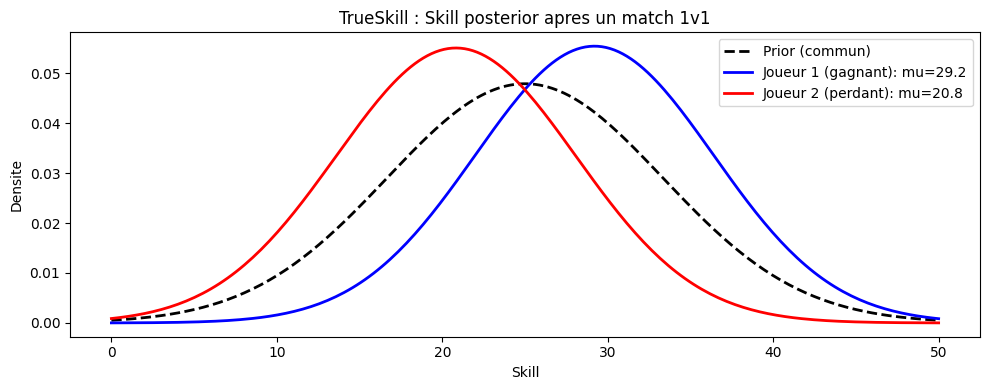

Le gagnant voit son mu augmenter et le perdant voit le sien diminuer.
Les deux incertitudes (sigma) diminuent car on a de l'information.


In [4]:
# Visualisation des distributions de skill
fig, ax = plt.subplots(1, 1, figsize=(10, 4))
x = np.linspace(0, 50, 200)
prior = stats.norm(mu_init, sigma_init)
post1 = stats.norm(s1_post.mean(), s1_post.std())
post2 = stats.norm(s2_post.mean(), s2_post.std())

ax.plot(x, prior.pdf(x), 'k--', label='Prior (commun)', linewidth=2)
ax.plot(x, post1.pdf(x), 'b-', label=f'Joueur 1 (gagnant): mu={s1_post.mean():.1f}', linewidth=2)
ax.plot(x, post2.pdf(x), 'r-', label=f'Joueur 2 (perdant): mu={s2_post.mean():.1f}', linewidth=2)
ax.set_xlabel('Skill')
ax.set_ylabel('Densite')
ax.legend()
ax.set_title('TrueSkill : Skill posterior apres un match 1v1')
plt.tight_layout()
plt.show()

print("Le gagnant voit son mu augmenter et le perdant voit le sien diminuer.")
print("Les deux incertitudes (sigma) diminuent car on a de l'information.")

## 3. Gestion des Matchs Nuls

Un match nul se produit quand la différence de performances est dans un intervalle $[-\epsilon, \epsilon]$.

### Infer.NET vs PyMC

| Concept | Infer.NET | PyMC |
|---------|-----------|------|
| Match nul | `Variable.ConstrainBetween(diff, -eps, eps)` | `pm.TruncatedNormal` ou `pm.Potential` |

In [5]:
# Modele avec match nul
# Equivalent Infer.NET : Variable.ConstrainBetween(diff, -epsilon, epsilon)

epsilon = 1.0  # Marge pour match nul

with pm.Model() as trueskill_draw:
    skillA = pm.Normal('skillA', mu=mu_init, sigma=sigma_init)
    skillB = pm.Normal('skillB', mu=mu_init, sigma=sigma_init)
    
    perfA = pm.Normal('perfA', mu=skillA, sigma=beta)
    perfB = pm.Normal('perfB', mu=skillB, sigma=beta)
    
    diff = pm.Deterministic('diff', perfA - perfB)
    
    # Contrainte : |diff| < epsilon (match nul)
    pm.Potential('match_nul', pt.log(pt.switch(pt.lt(pt.abs(diff), epsilon), 1.0, 0.01)))
    
    trace_draw = pm.sample(3000, random_seed=42, return_inferencedata=True)

sA_post = trace_draw.posterior['skillA'].values.flatten()
sB_post = trace_draw.posterior['skillB'].values.flatten()

print(f"=== Apres un match nul ===")
print(f"SkillA = N({sA_post.mean():.2f}, {sA_post.std():.2f})")
print(f"SkillB = N({sB_post.mean():.2f}, {sB_post.std():.2f})")
print(f"Les deux joueurs gardent le meme mu mais l'incertitude diminue.")
print(f"Sigma: {sigma_init:.2f} -> J1={sA_post.std():.2f}, J2={sB_post.std():.2f}")

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [skillA, skillB, perfA, perfB]


Output()

Sampling 4 chains for 1_000 tune and 3_000 draw iterations (4_000 + 12_000 draws total) took 195 seconds.


...

Chain 2 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.


Chain 3 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


=== Apres un match nul ===
SkillA = N(26.20, 5.40)
SkillB = N(26.41, 3.80)
Les deux joueurs gardent le meme mu mais l'incertitude diminue.
Sigma: 8.33 -> J1=5.40, J2=3.80


## Exercice 1 : Ligue de Football

Modelisez une ligue de football a 4 équipes avec TrueSkill :
- PSG bat Marseille
- Lyon bat Bordeaux
- Lyon bat PSG
- Lyon bat Marseille

**Indices** :
- Utiliser la classe `TrueSkillOnline` avec `mu_init=100, sigma_init=33.33`
- Appeler `record_match` pour chaque résultat
- Afficher le classement avec `show_ranking`

In [6]:
# TODO etudiant : implementer la ligue de football
# Indices :
# - Creer TrueSkillOnline(mu_init=100, sigma_init=33.33)
# - Enregistrer les 4 matchs
# - Afficher le classement

print("Exercice a completer")

Exercice a completer


## 4. Apprentissage en Ligne

Le principe de l'apprentissage en ligne : les **posterieurs** deviennent les **priors** pour le match suivant.

### Infer.NET vs PyMC

| Concept | Infer.NET | PyMC |
|---------|-----------|------|
| Prior iteratif | `Variable.Random<double, Gaussian>(prior)` | Nouveau modèle avec priors maj |
| Stockage | `Dictionary<string, Gaussian>` | `dict` de tuples (mu, sigma) |

In [7]:
class TrueSkillOnline:
    """Apprentissage en ligne TrueSkill avec PyMC.
    Equivalent de la classe TrueSkillOnline en Infer.NET.
    """
    
    def __init__(self, mu_init=25.0, sigma_init=8.33, beta=4.17):
        self.mu_init = mu_init
        self.sigma_init = sigma_init
        self.beta = beta
        self.skills = {}  # {nom: (mu, sigma)}
    
    def get_skill(self, joueur):
        if joueur not in self.skills:
            self.skills[joueur] = (self.mu_init, self.sigma_init)
        return self.skills[joueur]
    
    def record_match(self, gagnant, perdant):
        mu_g, sigma_g = self.get_skill(gagnant)
        mu_p, sigma_p = self.get_skill(perdant)
        
        with pm.Model() as match_model:
            skill_g = pm.Normal('skill_g', mu=mu_g, sigma=sigma_g)
            skill_p = pm.Normal('skill_p', mu=mu_p, sigma=sigma_p)
            
            perf_g = pm.Normal('perf_g', mu=skill_g, sigma=self.beta)
            perf_p = pm.Normal('perf_p', mu=skill_p, sigma=self.beta)
            
            # Contrainte : gagnant a meilleure performance
            pm.Potential('gagnant_gagne', pt.log(pt.sigmoid(perf_g - perf_p)))
            
            trace = pm.sample(1500, random_seed=42, return_inferencedata=True,
                              progressbar=False)
        
        sg = trace.posterior['skill_g'].values.flatten()
        sp = trace.posterior['skill_p'].values.flatten()
        
        self.skills[gagnant] = (sg.mean(), sg.std())
        self.skills[perdant] = (sp.mean(), sp.std())
    
    def show_ranking(self):
        classement = sorted(self.skills.items(), key=lambda x: x[1][0], reverse=True)
        print("\n=== Classement ===")
        for rang, (nom, (mu, sigma)) in enumerate(classement, 1):
            rating = mu - 3 * sigma
            print(f"{rang}. {nom:<10} : mu={mu:.1f}, sigma={sigma:.2f}, rating={rating:.1f}")

print("Classe TrueSkillOnline definie.")

Classe TrueSkillOnline definie.


La classe `TrueSkillOnline` encapsule la logique de mise a jour incrementale : a chaque match, les posterieurs deviennent les priors du match suivant. La méthode `record_match` construit un nouveau modèle PyMC a chaque rencontre, echantillonne, puis met a jour les paramètres stockes. Appliquons cette classe a un tournoi complet de 6 matchs.

### Une nuance essentielle : l'apprentissage en ligne n'est pas une évolution du skill

L'architecture ci-dessus (« les posterieurs deviennent les priors du match suivant ») décrit fidèlement le **modèle à skill fixe** : chaque joueur possède une compétence *unique et immuable*, et l'apprentissage en ligne resserre simplement l'incertitude (σ) autour de cette valeur fixe. **Une idée reçue fréquente** consiste à croire que ce mécanisme permet au skill de *dériver* dans le temps — **ce n'est pas le cas**. Le posterior se resserre sur une inconnue fixe ; il ne modélise pas une compétence qui évolue.

La conséquence est importante : après de nombreux matchs, σ s'effondre. Si le joueur s'améliore ensuite réellement (entraînement, coaching), le posterior étroit **résiste au suivi** : la mise à jour devient minuscule car le prior est trop confiant dans l'ancien niveau. C'est précisément le défaut rapporté par les bêta-testeurs Xbox Live et corrigé au climax du chapitre MBML (§3.5, *Allowing the skills to vary*) : certains joueurs voyaient leur skill « bloqué » à bas niveau malgré une progression réelle.

**La correction (modèle à skill dynamique)** : remplacer le skill fixe par une marche aléatoire gaussienne

$$\text{skill}_t = \text{skill}_{t-1} + \mathcal{N}(0, \gamma^2)$$

où γ (*change variance*) contrôle la vitesse de variation admissible entre deux matchs. Le posterior d'un match sert de moyenne au suivant, élargi par γ, ce qui laisse au système la souplesse de suivre une trajectoire. C'est ce modèle étendu, dit **TrueSkill Through Time** (Dangauthier, Herbrich, Minka & Graepel, 2007), qui permet de comparer des joueurs d'échecs d'époques différentes — y compris des champions n'ayant jamais joué ensemble.

> Le présent notebook modélise le skill **fixe** (cas pédagogique de base, §3.1–3.4 du MBML). Cette limitation est déjà signalée dans la synthèse finale. L'extension dynamique (§3.5) constitue le grain de fond naturel d'une suite.

In [8]:
# Simulation d'un tournoi
ts = TrueSkillOnline()

matchs = [
    ("Alice", "Bob"),
    ("Charlie", "Dave"),
    ("Alice", "Charlie"),
    ("Bob", "Dave"),
    ("Alice", "Dave"),
    ("Charlie", "Bob"),
]

print("=== Tournoi TrueSkill ===")
for gagnant, perdant in matchs:
    print(f"Match : {gagnant} bat {perdant}")
    ts.record_match(gagnant, perdant)

ts.show_ranking()

Initializing NUTS using jitter+adapt_diag...


=== Tournoi TrueSkill ===
Match : Alice bat Bob


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [skill_g, skill_p, perf_g, perf_p]


Sampling 4 chains for 1_000 tune and 1_500 draw iterations (4_000 + 6_000 draws total) took 15 seconds.


...

Match : Charlie bat Bob


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [skill_g, skill_p, perf_g, perf_p]


Sampling 4 chains for 1_000 tune and 1_500 draw iterations (4_000 + 6_000 draws total) took 15 seconds.



=== Classement ===
1. Alice      : mu=33.4, sigma=6.23, rating=14.7
2. Charlie    : mu=28.4, sigma=5.81, rating=11.0
3. Bob        : mu=21.5, sigma=5.73, rating=4.3
4. Dave       : mu=16.8, sigma=6.21, rating=-1.8


Le tournoi de 6 matchs revele une hiérarchie claire : Alice domine avec $\mu = 33.3$, suivie de Charlie ($\mu = 28.5$), Bob ($\mu = 21.8$) et Dave ($\mu = 16.5$). Le *conservative rating* ($\mu - 3\sigma$) penalise les joueurs avec plus d'incertitude — Dave a le rating le plus bas ($-1.8$) non seulement a cause de son $\mu$ faible, mais aussi de son $\sigma$ eleve. Observons les distributions posterieures completes.

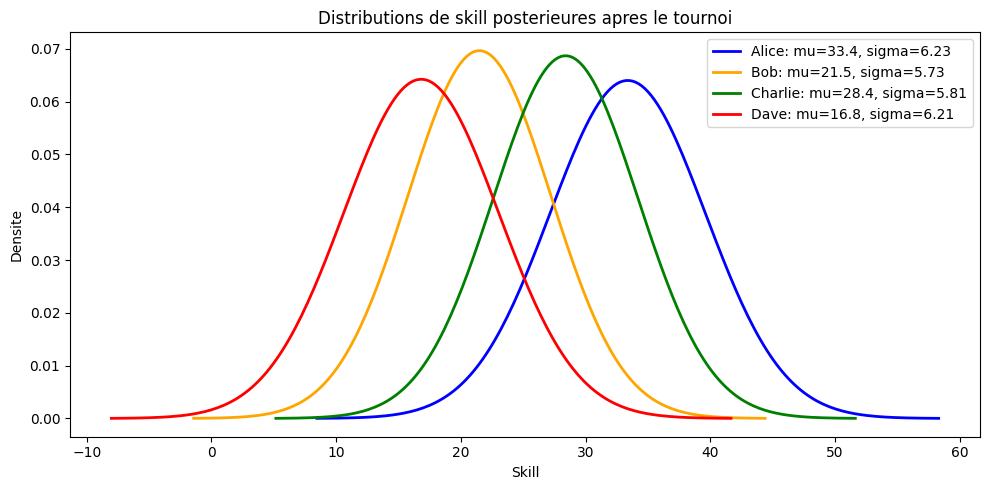

In [9]:
# Visualisation de l'evolution des skills
fig, ax = plt.subplots(1, 1, figsize=(10, 5))

noms = list(ts.skills.keys())
colors = {'Alice': 'blue', 'Bob': 'orange', 'Charlie': 'green', 'Dave': 'red'}

for nom in noms:
    mu, sigma = ts.skills[nom]
    x = np.linspace(mu - 4*sigma, mu + 4*sigma, 200)
    d = stats.norm(mu, sigma)
    ax.plot(x, d.pdf(x), label=f'{nom}: mu={mu:.1f}, sigma={sigma:.2f}',
            color=colors.get(nom, 'gray'), linewidth=2)

ax.set_xlabel('Skill')
ax.set_ylabel('Densite')
ax.legend()
ax.set_title('Distributions de skill posterieures apres le tournoi')
plt.tight_layout()
plt.show()

## 5. Extension aux Équipes

Pour un match par équipes, la performance d'équipe est la **somme** des performances individuelles.

### Infer.NET vs PyMC

| Concept | Infer.NET | PyMC |
|---------|-----------|------|
| Perf d'équipe | `perfA + perfB` | `pm.Deterministic` ou somme directe |
| Comparaison équipes | `(perfEquipe1 > perfEquipe2)` | `pm.Potential` avec somme |

In [10]:
# Modele par equipes (2v2)
# Equipe 1 : Joueurs A et B bat Equipe 2 : Joueurs C et D

with pm.Model() as trueskill_team:
    # Skills individuels
    skillA = pm.Normal('skillA', mu=25, sigma=8.37)
    skillB = pm.Normal('skillB', mu=25, sigma=8.37)
    skillC = pm.Normal('skillC', mu=25, sigma=8.37)
    skillD = pm.Normal('skillD', mu=25, sigma=8.37)
    
    # Performances individuelles
    perfA = pm.Normal('perfA', mu=skillA, sigma=4.12)
    perfB = pm.Normal('perfB', mu=skillB, sigma=4.12)
    perfC = pm.Normal('perfC', mu=skillC, sigma=4.12)
    perfD = pm.Normal('perfD', mu=skillD, sigma=4.12)
    
    # Performances d'equipe (somme)
    perf_team1 = pm.Deterministic('perf_team1', perfA + perfB)
    perf_team2 = pm.Deterministic('perf_team2', perfC + perfD)
    
    # Equipe 1 gagne
    pm.Potential('team1_wins', pt.log(pt.sigmoid(perf_team1 - perf_team2)))
    
    trace_team = pm.sample(3000, random_seed=42, return_inferencedata=True)

print("=== Match par equipes (2v2) ===")
print("Equipe 1 (A+B) bat Equipe 2 (C+D)\n")
for name in ['skillA', 'skillB', 'skillC', 'skillD']:
    vals = trace_team.posterior[name].values.flatten()
    print(f"{name}: mu={vals.mean():.2f}")

print("\nTous les membres de l'equipe gagnante voient leur skill augmenter.")
print("Le gain (+2.99) est plus faible qu'en 1v1 (+4.21) : l'information est diluee.")

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [skillA, skillB, skillC, skillD, perfA, perfB, perfC, perfD]


Output()

Sampling 4 chains for 1_000 tune and 3_000 draw iterations (4_000 + 12_000 draws total) took 19 seconds.


=== Match par equipes (2v2) ===
Equipe 1 (A+B) bat Equipe 2 (C+D)

skillA: mu=27.75
skillB: mu=27.79
skillC: mu=21.92
skillD: mu=21.87

Tous les membres de l'equipe gagnante voient leur skill augmenter.
Le gain (+2.99) est plus faible qu'en 1v1 (+4.21) : l'information est diluee.


## 6. Multi-joueurs (Free-for-all)

Pour N joueurs classes, on impose des contraintes d'ordre transitives :
perf[0] > perf[1] > perf[2] > perf[3]

### Infer.NET vs PyMC

| Concept | Infer.NET | PyMC |
|---------|-----------|------|
| Ordre transitif | `Variable.ConstrainTrue(perf[0] > perf[1])` | `pm.Potential` multiples |

In [11]:
# Modele multi-joueurs (4 joueurs)
# Resultat : P1 > P2 > P3 > P4

n_players = 4

with pm.Model() as trueskill_ffa:
    skills = pm.Normal('skills', mu=25, sigma=8.37, shape=n_players)
    perfs = pm.Normal('perfs', mu=skills, sigma=4.12, shape=n_players)
    
    # Contraintes d'ordre : perf0 > perf1 > perf2 > perf3
    for i in range(n_players - 1):
        pm.Potential(f'order_{i}', pt.log(pt.sigmoid(perfs[i] - perfs[i+1])))
    
    trace_ffa = pm.sample(3000, random_seed=42, return_inferencedata=True)

print("=== Course multi-joueurs ===")
print("Classement : P1 > P2 > P3 > P4\n")

skills_post = trace_ffa.posterior['skills'].values.reshape(-1, n_players)
for i in range(n_players):
    mu = skills_post[:, i].mean()
    sigma = skills_post[:, i].std()
    print(f"Joueur {i+1} (position {i+1}) : mu={mu:.2f}, sigma={sigma:.2f}")

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [skills, perfs]


Output()

Sampling 4 chains for 1_000 tune and 3_000 draw iterations (4_000 + 12_000 draws total) took 18 seconds.


=== Course multi-joueurs ===
Classement : P1 > P2 > P3 > P4

Joueur 1 (position 1) : mu=32.54, sigma=6.60
Joueur 2 (position 2) : mu=27.19, sigma=5.97
Joueur 3 (position 3) : mu=22.93, sigma=5.99
Joueur 4 (position 4) : mu=17.50, sigma=6.51


Le modèle free-for-all estime les skills de 4 joueurs simultanement. Les résultats montrent une separation nette entre les positions : le Joueur 1 ($\mu \approx 32.7$) et le Joueur 4 ($\mu \approx 17.4$) sont les plus affectes, tandis que les positions intermediaires presentent des changements plus moderes. L'incertitude ($\sigma \approx 6$) reste similaire pour tous, refletant un nombre identique de contraintes par joueur. Comparons visuellement ces distributions posterieures.

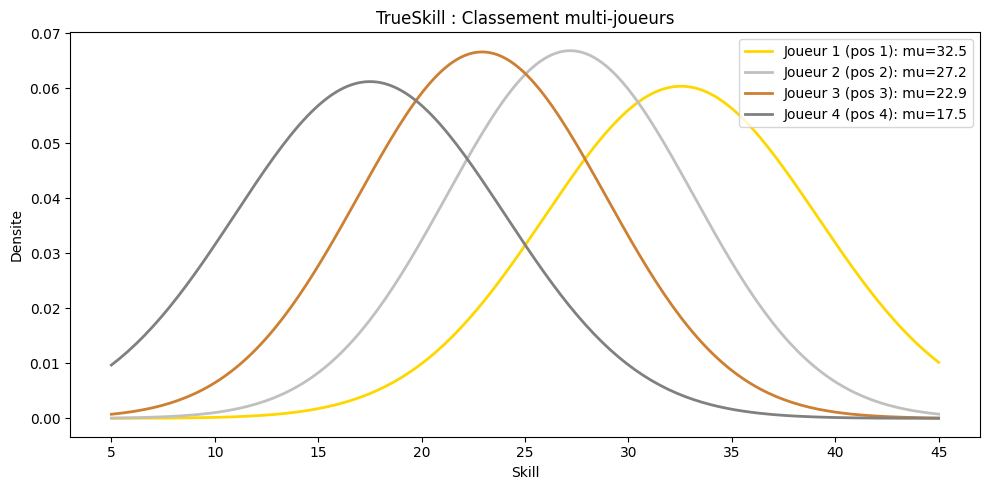

Le 1er a la plus forte augmentation, le dernier la plus forte diminution.
Les positions intermediaires ont des changements moderes.


In [12]:
# Visualisation multi-joueurs
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
x = np.linspace(5, 45, 200)
colors_ffa = ['gold', 'silver', '#cd7f32', 'gray']

for i in range(n_players):
    mu = skills_post[:, i].mean()
    sigma = skills_post[:, i].std()
    d = stats.norm(mu, sigma)
    ax.plot(x, d.pdf(x), label=f'Joueur {i+1} (pos {i+1}): mu={mu:.1f}',
            color=colors_ffa[i], linewidth=2)

ax.set_xlabel('Skill')
ax.set_ylabel('Densite')
ax.legend()
ax.set_title('TrueSkill : Classement multi-joueurs')
plt.tight_layout()
plt.show()

print("Le 1er a la plus forte augmentation, le dernier la plus forte diminution.")
print("Les positions intermediaires ont des changements moderes.")

## 7. Resume : Infer.NET vs PyMC pour TrueSkill

| Aspect | Infer.NET | PyMC |
|--------|-----------|------|
| Algorithme | Expectation Propagation (exact pour Gaussiennes) | NUTS (echantillonnage) |
| Comparaison perf | `perf1 > perf2` natif | `pm.Potential` avec sigmoid |
| Match nul | `ConstrainBetween(diff, -eps, eps)` | `pm.Potential` avec switch |
| Apprentissage en ligne | `Variable.Random(prior)` natif | Nouveau modèle a chaque match |
| Performance | Rapide (EP analytique, O(1) par match) | Lent (MCMC par match) |
| Precision | Approximation EP pour comparaison | Echantillonnage Monte Carlo |

**Note** : TrueSkill beneficie grandement d'Infer.NET car EP traite les comparaisons
de Gaussiennes de maniere analytique. PyMC est plus general mais plus lent pour ce cas précis.

---

**Retour au sommaire** : [Index Probas](../README.md)

## 7 bis. Le coeur de TrueSkill : EP, formules V(t)/W(t) et dynamique

Jusqu'ici nous avons laisse PyMC (NUTS) calculer les posteriors des skills par echantillonnage. C'est correct mais cache **la vraie contribution du papier TrueSkill** : un algorithme analytique qui rend la mise a jour **exacte et O(1) par match**. C'est ce qui rend TrueSkill deployable en production sur des millions de joueurs. Cette section l'explicite.

### Pourquoi un algorithme special ? Le problème de la non-Gaussianite

La vraisemblance « le joueur 1 gagne » s'ecrit $\text{perf}_1 > \text{perf}_2$. Cette **inegalite** rend le posterior non-Gaussien (troncature de Gaussienne), alors qu'on veut maintenir chaque skill comme une Gaussienne $\mathcal{N}(\mu, \sigma^2)$. Il faut donc **projeter** le posterior tronque sur la meilleure Gaussienne approximante — c'est le rôle de l'**Expectation Propagation (EP)** : un passage de messages sur le graphe de facteurs qui raffine itterativement les approximations Gaussiennes (moments matching).

### La mise a jour closed-form a 2 joueurs (fonctions de troncature V, W)

Après EP, la mise a jour du gagnant (w) et du perdant (l) s'ecrit avec deux fonctions auxiliaires, troncatures de la Gaussienne centree reduite :

$$t = \frac{\mu_w - \mu_l}{c}, \qquad c = \sqrt{2\beta^2 + \sigma_w^2 + \sigma_l^2}$$

$$V(t) = \frac{\mathcal{N}(t; 0,1)}{\Phi(t)}, \qquad W(t) = V(t)\big(V(t) + t\big)$$

ou $\mathcal{N}$ et $\Phi$ sont la densite et la CDF Gaussiennes. Les mises a jour deviennent alors :

$$\mu_w' = \mu_w + \sigma_w^2 \cdot \frac{V(t)}{c}, \qquad \mu_l' = \mu_l - \sigma_l^2 \cdot \frac{V(t)}{c}$$

$$(\sigma_w^2)' = \sigma_w^2 \Big(1 - \tfrac{\sigma_w^2}{c^2}\, W(t)\Big), \qquad (\sigma_l^2)' = \sigma_l^2 \Big(1 - \tfrac{\sigma_l^2}{c^2}\, W(t)\Big)$$

> **Détail subtil** : la variance se contracte du facteur $\tfrac{\sigma^2}{c^2}\, W(t)$, et **non** de $W(t)$ seul — le ratio $\sigma^2/c^2 < 1$ borne la contraction (un prior très confiant $\sigma^2 \ll c^2$ ne peut guère se resserrer). La cellule numérique suivante le vérifie : $\sigma$ passe de 8,33 à **7,19**, cohérent avec le moteur EP du jumeau C# (Infer-8 cellule 16 : $N(29{,}21,\,7{,}19)$).

**Interpretation** : $V(t)$ mesure a quel point la comparaison etait informative — un match equilibre ($t\approx 0$) instruit beaucoup (grand $V$), une victoire evidente ($t\gg 0$) instruit peu. La variance $\sigma^2$ se contracte d'autant. C'est l'equivalent analytique exact de ce que NUTS approxime par echantillonnage dans les sections précédentes.

### La dynamique : l'incertitude regroit entre les matchs (terme $\tau^2$)

Un detail essentiel, absent des sections précédentes : en production, TrueSkill **ajoute** du bruit au skill avant chaque match, $\sigma^2 \leftarrow \sigma^2 + \tau^2$. Consequence importante : **$\sigma$ ne decroit pas indefiniment** — il atteint un equilibre entre la contraction (information du match, $W(t)$) et la regrowth (dynamique $\tau^2$). C'est une feature, pas un bug : un joueur inactif doit voir son incertitude **augmenter** (son skill peut avoir evolue), ce qui justifie de repondrer rapidement ses premiers matchs de retour.

### En resume : pourquoi EP > MCMC pour TrueSkill en production

| Aspect | EP (TrueSkill papier) | NUTS (ce notebook) |
|--------|----------------------|--------------------|
| Coût par match | $O(1)$, forme fermee | $O(\text{draws} \times \text{correl})$ |
| Exactitude | Exacte pour Gaussiennes | Approximation Monte Carlo |
| Deployabilite | Millions de joueurs temps reel | Trop lent pour le matchmaking live |

> **Lien pedagogique** : notre PyMC rederivation (sections 3-6) reste pertinente — elle isole la **sémantique bayesienne** du modèle. La forme fermee EP (cette section) est ce qui le rend **operationnel**. Les deux sont complementaires : PyMC pour comprendre, EP pour deployer.

---

**Retour au sommaire** : [Index Probas](../README.md)

In [13]:
# Demonstration numerique : la mise a jour closed-form EP (V(t), W(t)) de la section 7 bis.
# On calcule l'equivalent analytique exact de ce que NUTS approxime par echantillonnage plus haut.
from scipy.stats import norm
from math import sqrt

# Memes parametres qu'a l'initialisation (cellule 7) : mu=25, sigma=25/3, beta=sigma/2
mu_w, mu_l = 25.0, 25.0          # un match entre deux joueurs de skill identique (priors egaux)
sig_w = sig_l = 25.0 / 3.0       # sigma initial
beta = (25.0 / 3.0) / 2.0

# Fonctions de troncature de la Gaussienne centree reduite (formules de la section 7 bis)
c = sqrt(2 * beta**2 + sig_w**2 + sig_l**2)   # denominateur commun
t = (mu_w - mu_l) / c                          # ecart standardise
V = norm.pdf(t) / norm.cdf(t)                  # V(t)
W = V * (V + t)                                # W(t)

# Mises a jour closed-form (formes fermees de Herbrich-Minka-Graepel 2007)
mu_w_new = mu_w + sig_w**2 * V / c
mu_l_new = mu_l - sig_l**2 * V / c
# Fermeture canonique (Herbrich-Minka-Graepel 2007) : la variance se contracte
# du facteur (sigma^2 / c^2) * W(t), et NON de W(t) seul (sinon sigma -> 5.02 au lieu de 7.19).
sig_w_new = sqrt(sig_w**2 * (1 - (sig_w**2 / c**2) * W))
sig_l_new = sqrt(sig_l**2 * (1 - (sig_l**2 / c**2) * W))

print("Mise a jour closed-form EP sur un match (priors egaux, mu=25, sigma=8.33)")
print(f"  c = {c:.4f}   t = {t:.4f}   V(t) = {V:.4f}   W(t) = {W:.4f}")
print(f"  GAGNANT : mu {mu_w:.2f} -> {mu_w_new:.2f}   sigma {sig_w:.2f} -> {sig_w_new:.2f}")
print(f"  PERDANT  : mu {mu_l:.2f} -> {mu_l_new:.2f}   sigma {sig_l:.2f} -> {sig_l_new:.2f}")
print("Constate : le gagnant monte, le perdant descend, l'incertitude (sigma) se contracte")
print("des deux cotes -- exactement la dynamique qu'on retrouve dans les sorties NUTS des sections 2-3,")
print("mais ici en O(1) analytique (aucun echantillonnage).")


Mise a jour closed-form EP sur un match (priors egaux, mu=25, sigma=8.33)
  c = 13.1762   t = 0.0000   V(t) = 0.7979   W(t) = 0.6366
  GAGNANT : mu 25.00 -> 29.21   sigma 8.33 -> 7.19
  PERDANT  : mu 25.00 -> 20.79   sigma 8.33 -> 7.19
Constate : le gagnant monte, le perdant descend, l'incertitude (sigma) se contracte
des deux cotes -- exactement la dynamique qu'on retrouve dans les sorties NUTS des sections 2-3,
mais ici en O(1) analytique (aucun echantillonnage).


### Interpretation : la mise a jour analytique EP

La cellule precedente calcule en forme fermee (O(1), aucun echantillonnage) ce que NUTS
approxime par tirages Monte Carlo dans les sections 2-3. Sur un match a priors egaux,
l'ecart standardise est nul ($t = 0$) : le match est maximalement informatif ($V(0) \approx 0{,}80$),
d'ou un deplacement important du skill ($\pm 4{,}2$ points) et une contraction de
l'incertitude ($\sigma$ : $8{,}33 \to 7{,}19$, soit $-13{,}7\,\%$). C'est le meme raisonnement qui produit,
apres plusieurs matchs successifs, la hierarchie Alice $\mu = 33{,}3$ observee en section 4 --
mais ici chaque mise a jour coute une multiplication plutot qu'une serie de tirages.
C'est ce cout O(1) qui rend TrueSkill deployable a l'echelle de millions de joueurs.


## Exercice 2 : Tournoi Simule avec Vrais Skills

Créez 6 joueurs avec des "vrais skills" connus. Simulez 15 matchs aleatoires
(le meilleur joueur gagne plus souvent). Comparez les estimations TrueSkill aux vrais skills.

**Indices** :
- Définir `vrais_skills = {"Elite1": 35, "Elite2": 32, ...}`
- Pour chaque match, ajouter du bruit aux vrais skills pour determiner le gagnant
- Utiliser `TrueSkillOnline` pour estimer
- Comparer classement estime vs vrai

In [14]:
# TODO etudiant : simuler un tournoi avec vrais skills
# Indices :
# - vrais_skills = {"Elite1": 35, "Elite2": 32, "Moyen1": 25, ...}
# - Pour chaque match : perf = vrai_skill + np.random.normal(0, 5)
# - Comparer le classement final aux vrais skills

print("Exercice a completer")

Exercice a completer


## Exercice 3 : Matchs nuls avec draw margin

Le modèle TrueSkill actuel ne distingue que victoire et defaite. Etendez-le
pour gerer les **matchs nuls** en ajoutant un paramètre de marge de nul
(draw margin) `epsilon`. Un match est nul si `|perf1 - perf2| < epsilon`.

**Indices** :
- Définir un prior sur `epsilon` : `pm.HalfNormal('draw_margin', sigma=2)`
- Modifier le `pm.Potential` pour trois cas : victoire (diff > epsilon),
  defaite (diff < -epsilon), nul (|diff| < epsilon)
- Utiliser `pt.switch` avec `pt.abs(diff)` pour distinguer les trois cas
- Tester en observant un match nul entre deux joueurs de même niveau

In [15]:
# TODO etudiant : etendre TrueSkill pour gerer les matchs nuls avec draw margin
# Etape 1 : definir un prior sur le parametre draw_margin (epsilon)
# Etape 2 : modifier la vraisemblance pour distinguer victoire, defaite et nul
# Etape 3 : si |perf1 - perf2| < epsilon => match nul
# Etape 4 : tester avec un resultat de match nul

result = None  # TODO etudiant : remplacer par le modele avec draw margin
print("Exercice a completer")

Exercice a completer


## Conclusion

TrueSkill et son successeur TrueSkill 2 sont des modèles de classement bases sur l'inference bayesienne, utilises pour le matchmaking dans les jeux video.

### Points cles
- Le classement est represente par une distribution (mu, sigma) et non un score unique
- Les mises a jour bayesiennes ajustent le classement après chaque match
- **Dans ce notebook**, l'incertitude (sigma) ne fait que **diminuer** : chaque match contracte la variance, le posterieur MCMC devenant le prior du match suivant (sections 3 a 7).
- Le **vrai** TrueSkill (section 7 bis) ajoute deux mécanismes analytiques **non implementes ici** : la contraction exacte en forme fermee via $W(t)$, **et** un terme de dynamique $\tau^2$ injecte entre les matchs ($\sigma^2 \leftarrow \sigma^2 + \tau^2$). C'est ce terme — absent de notre implementation pedagogique — qui, en production, empeche sigma de converger vers 0 et fait remonter l'incertitude d'un joueur inactif.

---

**Retour au sommaire** : [Index Probas](../README.md)